In [1]:
!python3 -m venv sailing-env
!source sailing-env/bin/activate
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 84.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 8.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 7.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 93.0 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [ipywidgets]5 [gymnasium]]widgets]


In [2]:
import sys
import os
import numpy as np

# Add the src directory to the path
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

# Import the BaseAgent class
from src.agents.base_agent import BaseAgent

In [3]:
from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario

In [14]:
class QLearningAgent(BaseAgent):
    """A simple Q-learning agent for the sailing environment using only local information."""
    
    def __init__(self, learning_rate=0.1, discount_factor=0.9, exploration_rate=0.1):
        super().__init__()
        self.np_random = np.random.default_rng()
        
        # Learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        
        # State discretization parameters
        self.position_bins = 8     # Discretize the grid into 64x64
        self.velocity_bins = 4     # Discretize velocity into 4 bins
        self.wind_bins = 8         # Discretize wind directions into 8 bins
        
        # Initialize Q-table
        # State space: position_x, position_y, velocity_direction, wind_direction
        # Action space: 9 possible actions
        self.q_table = {}
        
    def discretize_state(self, observation):
        """Convert continuous observation to discrete state for Q-table lookup."""
        # Extract position, velocity and wind from observation
        x, y = observation[0], observation[1]
        vx, vy = observation[2], observation[3]
        wx, wy = observation[4], observation[5]
        
        # Discretize position (assume 128x128 grid)
        grid_size = 128
        x_bin = min(int(x / grid_size * self.position_bins), self.position_bins - 1)
        y_bin = min(int(y / grid_size * self.position_bins), self.position_bins - 1)
        
        # Discretize velocity direction (ignoring magnitude for simplicity)
        v_magnitude = np.sqrt(vx**2 + vy**2)
        if v_magnitude < 0.1:  # If velocity is very small, consider it as a separate bin
            v_bin = 0
        else:
            v_direction = np.arctan2(vy, vx)  # Range: [-pi, pi]
            v_bin = int(((v_direction + np.pi) / (2 * np.pi) * (self.velocity_bins-1)) + 1) % self.velocity_bins
        
        # Discretize wind direction
        wind_direction = np.arctan2(wy, wx)  # Range: [-pi, pi]
        wind_bin = int(((wind_direction + np.pi) / (2 * np.pi) * self.wind_bins)) % self.wind_bins
        
        # Return discrete state tuple
        return (x_bin, y_bin, v_bin, wind_bin)
        
    def act(self, observation):
        """Choose an action using epsilon-greedy policy."""
        # Discretize the state
        state = self.discretize_state(observation)
        
        # Epsilon-greedy action selection
        if self.np_random.random() < self.exploration_rate:
            # Explore: choose a random action
            return self.np_random.integers(0, 9)
        else:
            # Exploit: choose the best action according to Q-table
            if state not in self.q_table:
                # If state not in Q-table, initialize it
                self.q_table[state] = np.zeros(9)
            
            # Return action with highest Q-value
            return np.argmax(self.q_table[state])
    
    def learn(self, state, action, reward, next_state):
        """Update Q-table based on observed transition."""
        # Initialize Q-values if states not in table
        if state not in self.q_table:
            self.q_table[state] = np.zeros(9)
        if next_state not in self.q_table:
            self.q_table[next_state] = np.zeros(9)
        
        # Q-learning update
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.discount_factor * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.learning_rate * td_error
    
    def reset(self):
        """Reset the agent for a new episode."""
        # Nothing to reset for Q-learning agent
        pass
        
    def seed(self, seed=None):
        """Set the random seed."""
        self.np_random = np.random.default_rng(seed)
        
    def save(self, path):
        """Save the Q-table to a file."""
        import pickle
        with open(path, 'wb') as f:
            pickle.dump(self.q_table, f)
            
    def load(self, path):
        """Load the Q-table from a file."""
        import pickle
        with open(path, 'rb') as f:
            self.q_table = pickle.load(f)

In [15]:
import math
# Create our Q-learning agent
ql_agent = QLearningAgent(learning_rate=0.1, discount_factor=0.995, exploration_rate=0.5)

np.random.seed(42)
ql_agent.seed(42)

env = SailingEnv(**get_wind_scenario('training_1'))
goal = env.goal_position.copy()
max_steps = 500

# Debug training: 10 episodes with reward shaping
print("Starting training with 10 episodes (debug run)...")
for episode in range(10):
    observation, info = env.reset(seed=episode)
    state = ql_agent.discretize_state(observation)
    prev_dist = np.linalg.norm(info['position'] - goal)
    total_reward = 0
    
    for step in range(max_steps):
        action = ql_agent.act(observation)
        next_observation, reward, done, truncated, info = env.step(action)
        next_state = ql_agent.discretize_state(next_observation)
        
        #Reward 

        #VMG reward
        curr_speed = math.sqrt((info['velocity'][0])**2 + (info['velocity'][1])**2 )
        curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        curr_angle_to_goal = math.atan2(goal[1] - info['position'][1], goal[0] - info['position'][0])
        theta = curr_angle_boat - curr_angle_to_goal
        vmg_reward = curr_speed * math.cos(theta)

        #angle wind reward 
        curr_angle_wind = math.degrees(math.atan2(info['wind'][1], info['wind'][0]))
        curr_angle_boat = math.degrees(math.atan2(info['velocity'][1], info['velocity'][0]))
        curr_angle = abs(curr_angle_wind - curr_angle_boat)
        if curr_angle > 180 :
            curr_angle = 360 - curr_angle
        curr_angle = 180 - curr_angle
        if curr_angle < 40:
            wind_reward = -1.0
        elif curr_angle < 50:
            wind_reward = 0.4
        elif curr_angle < 80:
            wind_reward = 0.6
        elif curr_angle < 100:
            wind_reward = 1.0
        elif curr_angle < 150:
            wind_reward = 0.8
        else:
            wind_reward = 0.4
        
        #speed reward 
        speed_reward = -0.1

        #distance reward
        curr_dist = np.linalg.norm(info['position'] - goal) 
        distance_reward = prev_dist - ql_agent.discount_factor*curr_dist

        shaped_reward = reward + speed_reward + distance_reward + 0.2*vmg_reward + wind_reward

        if info.get('is_stuck', False):
            shaped_reward = -10.0
        prev_dist = curr_dist
        
        ql_agent.learn(state, action, shaped_reward, next_state)
        state = next_state
        observation = next_observation
        total_reward += reward
        
        if done or truncated:
            break

    print(f"Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")
    ql_agent.exploration_rate = max(0.05, ql_agent.exploration_rate * 0.99)

print(f"\nDebug training completed! Q-table size: {len(ql_agent.q_table)} states")

Starting training with 10 episodes (debug run)...
Episode 1: Steps=11, Reward=0.0, Position=[62 21], Goal reached=True
Episode 2: Steps=9, Reward=0.0, Position=[65 18], Goal reached=True
Episode 3: Steps=23, Reward=0.0, Position=[54 27], Goal reached=True
Episode 4: Steps=9, Reward=0.0, Position=[65 20], Goal reached=True
Episode 5: Steps=18, Reward=0.0, Position=[53 29], Goal reached=True
Episode 6: Steps=15, Reward=0.0, Position=[68 23], Goal reached=True
Episode 7: Steps=21, Reward=0.0, Position=[45 37], Goal reached=True
Episode 8: Steps=38, Reward=0.0, Position=[47 35], Goal reached=True
Episode 9: Steps=9, Reward=0.0, Position=[62 20], Goal reached=True
Episode 10: Steps=46, Reward=0.0, Position=[43 38], Goal reached=True

Debug training completed! Q-table size: 39 states


In [23]:
# Full training across all 3 wind scenarios with reward shaping
ql_agent_full = QLearningAgent(learning_rate=0.1, discount_factor=0.995, exploration_rate=0.5)
max_steps = 500

np.random.seed(42)
ql_agent_full.seed(42)

scenarios = ['training_1', 'training_2', 'training_3']
num_episodes = 2000

rewards_history = []
steps_history = []
success_history = []

import time
start_time = time.time()
print(f"Starting full training with {num_episodes} episodes across 3 scenarios...")

for episode in range(num_episodes):
    scenario = scenarios[episode % 3]
    env = SailingEnv(**get_wind_scenario(scenario))
    goal = env.goal_position.copy()
    
    observation, info = env.reset(seed=episode)
    state = ql_agent_full.discretize_state(observation)
    prev_dist = np.linalg.norm(info['position'] - goal)
    total_reward = 0
    
    for step in range(max_steps):
        action = ql_agent_full.act(observation)
        next_observation, reward, done, truncated, info = env.step(action)
        next_state = ql_agent_full.discretize_state(next_observation)
        
        #Reward 

        #VMG reward
        curr_speed = math.sqrt((info['velocity'][0])**2 + (info['velocity'][1])**2 )
        curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        curr_angle_to_goal = math.atan2(goal[1] - info['position'][1], goal[0] - info['position'][0])
        theta = curr_angle_boat - curr_angle_to_goal
        vmg_reward = curr_speed * math.cos(theta)

        #angle wind reward 
        curr_angle_wind = math.degrees(math.atan2(info['wind'][1], info['wind'][0]))
        curr_angle_boat = math.degrees(math.atan2(info['velocity'][1], info['velocity'][0]))
        curr_angle = abs(curr_angle_wind - curr_angle_boat)
        if curr_angle > 180 :
            curr_angle = 360 - curr_angle
        curr_angle = 180 - curr_angle
        if curr_angle < 40:
            wind_reward = -1.0
        elif curr_angle < 50:
            wind_reward = 0.4
        elif curr_angle < 80:
            wind_reward = 0.6
        elif curr_angle < 100:
            wind_reward = 1.0
        elif curr_angle < 150:
            wind_reward = 0.8
        else:
            wind_reward = 0.4
        
        #speed reward 
        speed_reward = -0.2

        #distance reward
        curr_dist = np.linalg.norm(info['position'] - goal) 
        distance_reward = prev_dist - ql_agent.discount_factor*curr_dist

        shaped_reward = reward + speed_reward + 0.1*distance_reward + 0.1*vmg_reward + 0.5*wind_reward
        
        if info.get('is_stuck', False):
            shaped_reward = -10.0
        prev_dist = curr_dist
        
        ql_agent_full.learn(state, action, shaped_reward, next_state)
        state = next_state
        observation = next_observation
        total_reward += reward
        
        if done or truncated:
            break

    rewards_history.append(total_reward)
    steps_history.append(step + 1)
    success_history.append(done)
    ql_agent_full.exploration_rate = max(0.05, ql_agent_full.exploration_rate * 0.998)
    
    if (episode + 1) % 500 == 0:
        recent = success_history[-100:]
        print(f"Episode {episode+1}/{num_episodes}: Success rate (last 100): {sum(recent)/len(recent)*100:.1f}%")

training_time = time.time() - start_time
success_rate = sum(success_history) / len(success_history) * 100
print(f"\nTraining completed in {training_time:.1f} seconds!")
print(f"Overall success rate: {success_rate:.1f}%")
print(f"Q-table size: {len(ql_agent_full.q_table)} states")

Starting full training with 2000 episodes across 3 scenarios...
Episode 500/2000: Success rate (last 100): 100.0%
Episode 1000/2000: Success rate (last 100): 100.0%
Episode 1500/2000: Success rate (last 100): 100.0%
Episode 2000/2000: Success rate (last 100): 100.0%

Training completed in 292.8 seconds!
Overall success rate: 99.8%
Q-table size: 1180 states


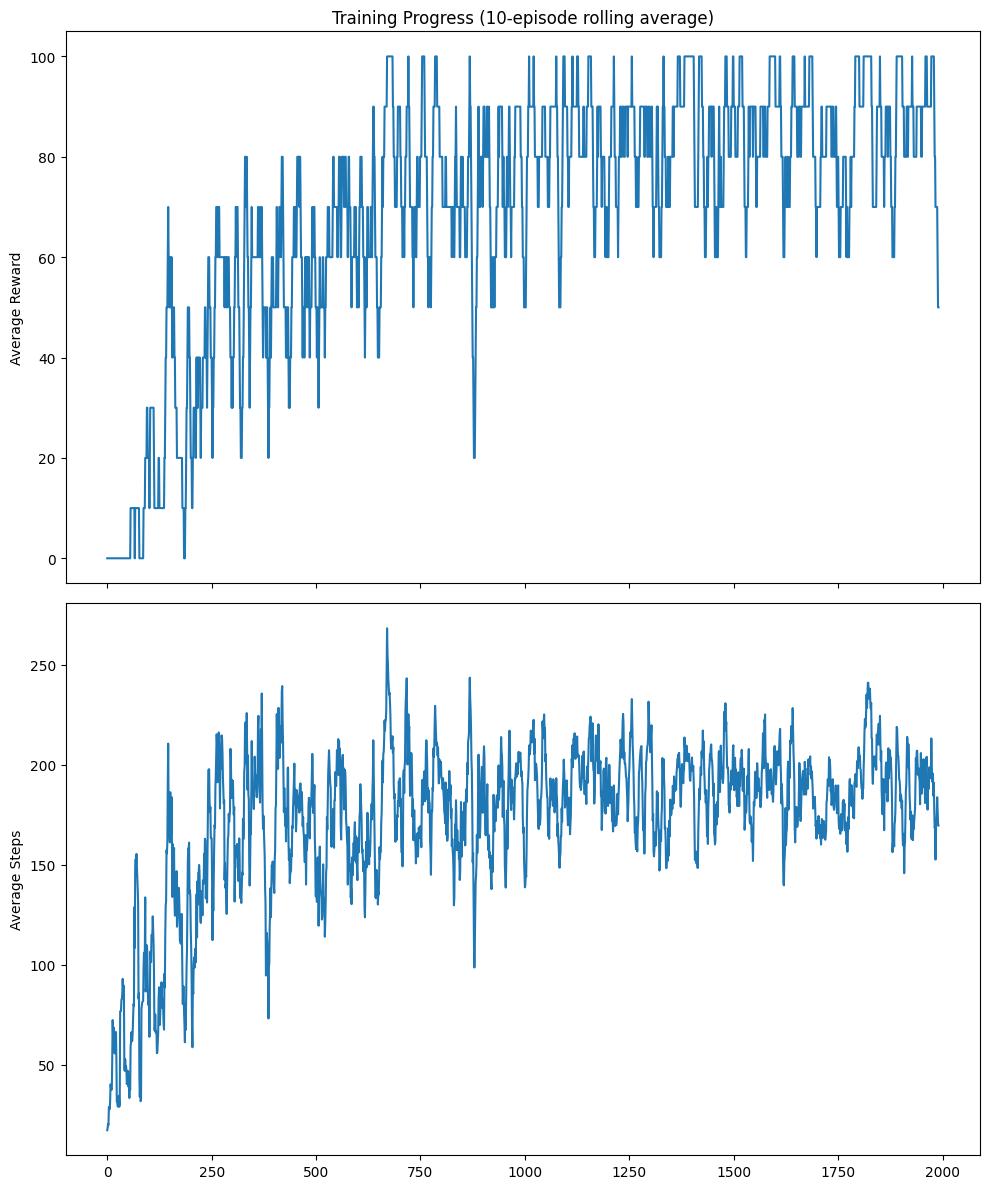

In [24]:
import matplotlib.pyplot as plt

# Calculate rolling averages
window_size = 10
rolling_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
rolling_steps = np.convolve(steps_history, np.ones(window_size)/window_size, mode='valid')
rolling_success = np.convolve([1 if s else 0 for s in success_history], np.ones(window_size)/window_size, mode='valid') * 100

# Create the plots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot rewards
ax1.plot(rolling_rewards)
ax1.set_ylabel('Average Reward')
ax1.set_title('Training Progress (10-episode rolling average)')

# Plot steps
ax2.plot(rolling_steps)
ax2.set_ylabel('Average Steps')

# Plot success rate
#ax3.plot(rolling_success)
#ax3.set_ylabel('Success Rate (%)')
#ax3.set_xlabel('Episode')

plt.tight_layout()
plt.show()

In [25]:
# Turn off exploration for evaluation
ql_agent_full.exploration_rate = 0

# Create test environment
test_env = SailingEnv(**get_wind_scenario('training_1'))

# Test parameters
num_test_episodes = 5
max_steps = 500

print("Testing the trained agent on 5 new episodes...")
# Testing loop
for episode in range(num_test_episodes):
    # Reset environment
    observation, info = test_env.reset(seed=1000 + episode)  # Different seeds from training
    
    total_reward = 0
    
    for step in range(max_steps):
        # Select action using learned policy
        action = ql_agent_full.act(observation)
        observation, reward, done, truncated, info = test_env.step(action)
        
        total_reward += reward
        
        # Break if episode is done
        if done or truncated:
            break
    
    print(f"Test Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")

Testing the trained agent on 5 new episodes...
Test Episode 1: Steps=187, Reward=100.0, Position=[ 65 126], Goal reached=True
Test Episode 2: Steps=188, Reward=100.0, Position=[ 64 127], Goal reached=True
Test Episode 3: Steps=174, Reward=0.0, Position=[38 84], Goal reached=True
Test Episode 4: Steps=155, Reward=100.0, Position=[ 64 127], Goal reached=True
Test Episode 5: Steps=82, Reward=0.0, Position=[47 34], Goal reached=True
